In [ ]:
#NOTE: the embedded HTML/CSS/JS will load the most recent publicly 
# released `arcgis-map-ipywidget` npm packge from unpkg.com
# (ex https://unpkg.com/arcgis-map-ipywidget@1.8.2/dist/index.js)
# If you are working on a development unreleased version of the API,
# this `arcgis-map-ipywidget` npm package will NOT have been published
# yet. To get HTML previews, run the below cell to copy the most recent 
# LOCALLY built npm package JS files to the SAME DIRECTORY as the 
# this notebook file, exported HTML, HTML preview, etc. The embedded
# HTML preview will pull from this local JS file before unpkg
#
# See https://bit.ly/3hKzbfd for more info

from copy_local_embed_widget_js_to_this_dir import \
     copy_local_embed_widget_js_to_this_dir
out = copy_local_embed_widget_js_to_this_dir()
print(f"{out} written successfully")

In [ ]:
from arcgis.gis import GIS
from arcgis.features import FeatureLayer
gis = GIS()
feature_layer = FeatureLayer(
    url="https://sampleserver6.arcgisonline.com/arcgis/rest/services/Hurricanes/MapServer/0")

map = gis.map("Atlantic Ocean", mode="3D")
map.extent = {'spatialReference': {'latestWkid': 3857, 'wkid': 102100},
 'xmin': -14099004.655239914,
 'ymin': 217234.000433374,
 'xmax': 1350499.6438515757,
 'ymax': 8620644.192136217}
map.zoom = 4
map.tilt = 20

renderer = {"renderer": "autocast", #This tells python to use JS autocasting
  "type": "simple",  # JS type of new SimpleRenderer()
  "symbol": {
    "type": "point-3d",  #JS type of new PointSymbol3D()
    "symbolLayers": [{  
      "type": "object",  #JS type of new ObjectSymbol3DLayer()
      "resource": { "primitive": "cone" },
      "width": 50000
    }]
  },
  "visualVariables": [{ #JS configuration of visualVariables
    "type": "color",
    "field": "PRESSURE", 
    "stops": [
      { "value": 950, "color": "red" },
      { "value": 1020, "color": "blue" }
    ]
  }, {
    "type": "size",
    "field": "WINDSPEED",
    "stops": [
      { "value": 20, "size": 60000 },
      { "value": 150, "size": 500000 }
    ],
    "axis": "height"
  }, {
    "type": "size",
    "axis": "width-and-depth",
    "useSymbolValue": True
  }]
};
map.add_layer(feature_layer, renderer)
map

In [ ]:
# Should look like the above map, being interactive etc
map.embed(set_as_preview=False)

### Should look like this, be interactive, etc.:

<img src=" 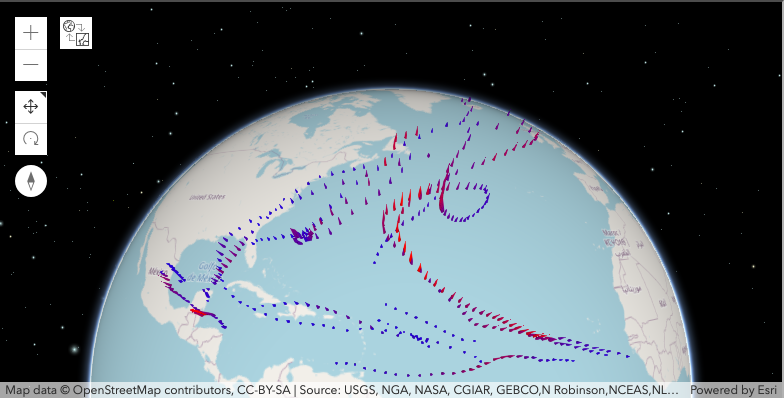"/>